# Seasonal distributions of a 3-hourly surface flux (ERA5)

Plots the **probability density** of a time–lat–lon field for each of the
four standard seasons (DJF/MAM/JJA/SON), pooling all 3-hourly samples and
grid points within a chosen region and year range.

Currently wired up for **ERA5 3-hourly** surface fluxes:

* `shflx` → `sshf`  — surface sensible heat flux (W m$^{-2}$)
* `lhflx` → `slhf`  — surface latent heat flux (W m$^{-2}$)

Switch between them by changing `VAR` in the config cell.

A `DATASETS` registry is used so a second (model) 3-hourly dataset can be
added later as a new entry and will be overlaid automatically on every
panel with no other code change.

Sign convention in this "clean" archive is **positive upward** (i.e., a
positive value means heat is leaving the surface — same convention as
CAM `SHFLX` / `LHFLX`), *not* the raw ERA5 "positive downward" storage.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import numpy as np
import xarray as xr
import dask.array as darr
import matplotlib.pyplot as plt

FIG_DIR = "/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/"
os.makedirs(FIG_DIR, exist_ok=True)


## Configuration

Change `VAR` to `"shflx"` or `"lhflx"`.  `REGION` is either `None` for a
global pool or a dict of `lat_min/lat_max/lon_min/lon_max` (longitude in
0–360).  `YEAR_RANGE` is inclusive.


In [2]:
# ── Which flux to analyse ────────────────────────────────────────────────
VAR = "shflx"        # "shflx", "lhflx", "t2m", or "sst"

# ── Per-variable metadata (paths, netcdf variable name, plotting bins) ──
VAR_META = {
    "shflx": {
        "root":      "/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/shflx/clean_3hr",
        "pattern":   "shflx_*_era5_3hr_clean.nc",
        "nc_var":    "sshf",
        "long_name": "Surface sensible heat flux",
        "units":     "W m$^{-2}$",
        # 5 W/m^2 bins.  Data is positive-up (heat leaving surface), so the
        # tail sits on the +ve side; keep some -ve headroom for stable / warm
        # advection cases where the atmosphere heats the surface.
        "bins":      np.arange(-200.0, 600.0 + 1, 5.0),
    },
    "lhflx": {
        "root":      "/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/lhflx/clean_3hr",
        "pattern":   "lhflx_*_era5_3hr_clean.nc",
        "nc_var":    "slhf",
        "long_name": "Surface latent heat flux",
        "units":     "W m$^{-2}$",
        "bins":      np.arange(-200.0, 700.0 + 1, 5.0),
    },
    "t2m": {
        "root":      "/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/t2/clean_3hr",
        "pattern":   "t2_*_era5_3hr_clean.nc",
        "nc_var":    "t2m",
        "long_name": "2-m air temperature",
        "units":     "K",
        # 1 K bins covering the observed global range; matches the
        # TREFHT axis in JOINT_VAR_META so the 1-D and 2-D flows share a grid.
        "bins":      np.arange(220.0, 310.0 + 1, 1.0),
    },
    "sst": {
        "root":      "/glade/derecho/scratch/rneale/ERA5/download/dcycle_3hrave/sst/clean_3hr",
        "pattern":   "sst_*_era5_3hr_clean.nc",
        "nc_var":    "sst",
        "long_name": "Sea-surface temperature (skin, ocean only)",
        "units":     "K",
        # Ocean-only skin temp; land is already NaN, so the
        # subtraction naturally stays masked over land.  Range chosen to
        # cover sea-ice edge (~271 K) to warm-pool values (~305 K).
        "bins":      np.arange(270.0, 310.0 + 1, 0.5),
    },
}

# ── Analysis window ─────────────────────────────────────────────────────
YEAR_RANGE = (1979, 1982)          # inclusive

# ── Spatial pool ────────────────────────────────────────────────────────
# None → global (all lat/lon).
# Or a dict, e.g. Labrador Sea box:
REGION = {"lat_min": 55.0, "lat_max": 65.0,
          "lon_min": 300.0, "lon_max": 310.0}
# REGION = None

# ── Standard 4 seasons ──────────────────────────────────────────────────
SEASONS = ["DJF", "MAM", "JJA", "SON"]

# ── 2-D joint PDF: which two h1i variables to bin on X and Y ────────────
# Any pair drawn from:
#   SHFLX, LHFLX        — surface fluxes (W m^-2, positive up)
#   TS, TREFHT          — surface / 2-m air temperature (K)
#   TS_MINUS_TREFHT     — TS - TREFHT (K).  Big positive → unstable surface
#                          layer (e.g., cold air over warmer ocean).
JOINT_X = "TS_MINUS_TREFHT"
JOINT_Y = "SHFLX"

# Per-axis metadata (bin edges + labels).  Tweak bin ranges to zoom.
JOINT_VAR_META = {
    "SHFLX":           {"bins": np.arange(-200,  600 + 1,   5.0),
                        "long": "SHFLX",       "units": "W m$^{-2}$"},
    "LHFLX":           {"bins": np.arange(-200,  700 + 1,   5.0),
                        "long": "LHFLX",       "units": "W m$^{-2}$"},
    "TS":              {"bins": np.arange( 220,  310 + 1,   1.0),
                        "long": "TS",          "units": "K"},
    "TREFHT":          {"bins": np.arange( 220,  310 + 1,   1.0),
                        "long": "TREFHT",      "units": "K"},
    "TS_MINUS_TREFHT": {"bins": np.arange( -20,   40 + 0.01, 0.5),
                        "long": "TS − TREFHT", "units": "K"},
}

# ── Thresholds for the "% time above threshold" plots ───────────────────
# One value per axis variable; None → skip that variable.  Used by the
# threshold-exceedance plotting cell below.
THRESHOLDS = {
    "SHFLX":           300.0,   # W m^-2
    "LHFLX":           300.0,   # W m^-2
    "TS_MINUS_TREFHT":   10.0,   # K
    "TS":              None,
    "TREFHT":          None,
}

# ── Sea-ice mask ─────────────────────────────────────────────────────────
# ERA5 variables in SEAICE_ERA5_VARS have grid points with
# ICEFRAC >= SEAICE_FRAC_THRESHOLD masked out in all analyses
# (1-D PDFs, joint PDFs, maps).  Applied to ERA5 cases only.
# ICEFRAC is read from pre-computed seasonal CAM climo files.
SEAICE_FRAC_THRESHOLD = 0.2
SEAICE_ERA5_VARS      = {"TS", "TREFHT", "TS_MINUS_TREFHT"}
SEAICE_CLIMO_DIR    = ("/glade/derecho/scratch/rneale/archive/"
                       "f.e30.FLTHIST.CAM7.L32.000a/climo")
SEAICE_CLIMO_PREFIX = "f.e30.FLTHIST.CAM7.L32.000a"

# ── Cases to overlay in the 2-D joint PDF ────────────────────────────────
# One dict per case — the joint-PDF section below iterates over this list.
# Duplicate a CAM entry (or add a new one) to compare two model runs; drop
# the ERA5 entry to compare model runs against each other only.
#
#   kind="era5"  → uses VAR_META["shflx"|"lhflx"|"t2m"|"sst"]["root"] (fixed ERA5 archive)
#   kind="cam"   → uses `case_root` + `stream` (default h1i, instantaneous)
JOINT_CASES = [
#    {"name": "ERA5",
#     "kind": "era5",
#     "year_range": (1979, 1982)},
    {"name": "CAM7-001",
     "kind": "cam",
     "case_root": ("/glade/derecho/scratch/rneale/archive/"
                   "f.cam6_4_202.FHISTC_LTso_ne30.cam7.001/atm/hist"),
     "stream":    "h1i",
    "year_range": (1979, 1982)},
    # Uncomment / duplicate to add another CAM case:
    {"name": "CAM7-002",
      "kind": "cam",
      "case_root": ("/glade/derecho/scratch/rneale/archive/"
                    "f.cam6_4_202.FHISTC_LTso_ne30.cam7.002/atm/hist"),
      "stream":    "h1i",
      "year_range": (1979, 1982)},
]

meta = VAR_META[VAR]
print(f"variable   : {VAR}  ({meta['nc_var']})")
print(f"years      : {YEAR_RANGE[0]}–{YEAR_RANGE[1]}")
print(f"region     : {REGION}")
print(f"bins       : {meta['bins'][0]:g} … {meta['bins'][-1]:g}  "
      f"(n={len(meta['bins'])-1}, width={meta['bins'][1]-meta['bins'][0]:g})")
print(f"joint cases: {[c['name'] for c in JOINT_CASES]}")
print(f"joint axes : x={JOINT_X}, y={JOINT_Y}")
print(f"thresholds : "
      f"{JOINT_X}>{THRESHOLDS.get(JOINT_X)}, "
      f"{JOINT_Y}>{THRESHOLDS.get(JOINT_Y)}")
print(f"sea-ice    : ICEFRAC < {SEAICE_FRAC_THRESHOLD} for ERA5 vars "
      f"{SEAICE_ERA5_VARS}, climo from {SEAICE_CLIMO_PREFIX}")

variable   : shflx  (sshf)
years      : 1979–1982
region     : {'lat_min': 55.0, 'lat_max': 65.0, 'lon_min': 300.0, 'lon_max': 310.0}
bins       : -200 … 600  (n=160, width=5)
joint cases: ['CAM7-001', 'CAM7-002']
joint axes : x=TS_MINUS_TREFHT, y=SHFLX
thresholds : TS_MINUS_TREFHT>10.0, SHFLX>300.0
sea-ice    : ICEFRAC < 0.2 for ERA5 vars {'TS', 'TS_MINUS_TREFHT', 'TREFHT'}, climo from f.e30.FLTHIST.CAM7.L32.000a


## Domain preview

Quick sanity-check map of the `REGION` box — everything below pools samples
from grid cells inside this rectangle.  If `REGION` is `None`, the whole
globe is shown as a reminder that the pool is global.


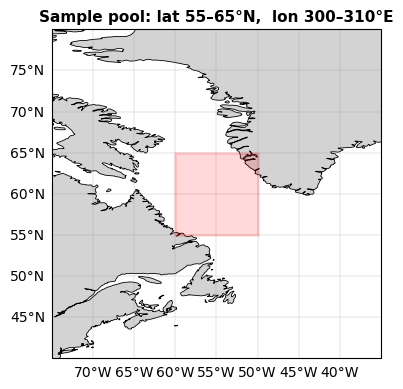

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches


def plot_domain(region, pad=15.0):
    proj = ccrs.PlateCarree()
    fig  = plt.figure(figsize=(5.5, 4.0))
    ax   = fig.add_subplot(1, 1, 1, projection=proj)

    if region is None:
        ax.set_global()
    else:
        ax.set_extent([region["lon_min"] - pad, region["lon_max"] + pad,
                       max(-90, region["lat_min"] - pad),
                       min( 90, region["lat_max"] + pad)],
                      crs=proj)

    ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white",     zorder=0)
    ax.coastlines(resolution="50m", linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if region is not None:
        rect = mpatches.Rectangle(
            (region["lon_min"], region["lat_min"]),
            region["lon_max"] - region["lon_min"],
            region["lat_max"] - region["lat_min"],
            linewidth=1.8, edgecolor="red", facecolor="red",
            alpha=0.15, transform=proj, zorder=5,
        )
        ax.add_patch(rect)
        ax.set_title(
            f"Sample pool: lat {region['lat_min']:g}–{region['lat_max']:g}°N,  "
            f"lon {region['lon_min']:g}–{region['lon_max']:g}°E",
            fontsize=11, fontweight="bold",
        )
    else:
        ax.set_title("Sample pool: global", fontsize=11, fontweight="bold")

    fig.tight_layout()
    return fig, ax


plot_domain(REGION)
plt.show()


## Optional Dask cluster

A local threaded scheduler is fine for a single-year test; for the full
1979–2013 record on a Lab-Sea sub-domain it pays to bring up a PBS cluster.
Uncomment the block to use one.


In [4]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster
#
cluster = PBSCluster(
     account="P03010039",
     interface="ext",
     walltime="04:00:00",
     queue="main",
     cores=4,
     memory="32GB",
     processes=4,
     local_directory="/glade/derecho/scratch/rneale/dask-temp",
     log_directory="/glade/derecho/scratch/rneale/dask-logs",
 )
cluster.scale(jobs=8)
client = Client(cluster)
client


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc67.hpc.ucar.edu/16103/proxy/8787/status,
Dashboard: /node/crhtc67.hpc.ucar.edu/16103/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.175:36531,Workers: 0
Dashboard: /node/crhtc67.hpc.ucar.edu/16103/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


## Loaders

`load_era5_3hr` opens the per-year files as a single lazy dataset, keeps
only the requested flux variable, and (optionally) slices to the region
box and year range.

Latitude in ERA5 is stored **north → south**, so the slice arguments are
ordered accordingly.


In [5]:
def load_era5_3hr(var, year_range=None, region=None, chunks=None):
    m = VAR_META[var]
    files = sorted(glob.glob(os.path.join(m["root"], m["pattern"])))
    if year_range is not None:
        y0, y1 = year_range
        keep = []
        for f in files:
            stem = os.path.basename(f)
            try:
                yy = int(stem.split("_")[1])   # {var}_{YYYY}_era5_3hr_clean.nc
            except (IndexError, ValueError):
                continue
            if y0 <= yy <= y1:
                keep.append(f)
        files = keep
    if not files:
        raise FileNotFoundError(f"No ERA5 {var} files found in {m['root']}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks=chunks or {"valid_time": 240},   # ~30 days per chunk
        parallel=False,
        preprocess=lambda d: d[[m["nc_var"]]],
    )
    da = ds[m["nc_var"]]

    if region is not None:
        # ERA5 latitudes are stored 90 → -90, so pass the slice in that order
        da = da.sel(
            latitude=slice(region["lat_max"], region["lat_min"]),
            longitude=slice(region["lon_min"], region["lon_max"]),
        )
    return da


def load_cam_3hr(case_root, var, year_range=None, region=None,
                 stream="h1i", chunks=None):
    """Open a CAM 3-hourly stream (default h1i, instantaneous) as a lazy
    DataArray for one variable.  Sign convention is already positive-up."""
    files = sorted(glob.glob(os.path.join(
        case_root, f"*.cam.{stream}.*.nc")))
    if year_range is not None:
        y0, y1 = year_range
        keep = []
        for f in files:
            # trailing pattern: .{stream}.YYYY-MM-DD-SSSSS.nc
            stem = os.path.basename(f)
            try:
                yy = int(stem.split(f".{stream}.")[1][:4])
            except (IndexError, ValueError):
                continue
            if y0 <= yy <= y1:
                keep.append(f)
        files = keep
    if not files:
        raise FileNotFoundError(
            f"No CAM {stream} files in {case_root} for {year_range}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks=chunks or {"time": 240},
        parallel=False,
        preprocess=lambda d: d[[var]],
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
    )
    da = ds[var]

    if region is not None:
        # CAM lat is stored south → north — ascending slice.
        da = da.sel(
            lat=slice(region["lat_min"], region["lat_max"]),
            lon=slice(region["lon_min"], region["lon_max"]),
        )
    return da


# Which axis variables can each backend supply?
_ERA5_SUPPORTED = {"SHFLX", "LHFLX", "TREFHT", "TS"}
_ERA5_KEY       = {"SHFLX": "shflx", "LHFLX": "lhflx", "TREFHT": "t2m", "TS": "sst"}


def load_axis(cfg, key, year_range, region):
    """Return a lazy DataArray for one axis variable from one case.

    `key` is a JOINT_VAR_META key: SHFLX, LHFLX, TS, TREFHT, TS_MINUS_TREFHT.
    Handles the TS_MINUS_TREFHT derivation on the CAM side.  Returns None
    if the backend can't provide `key` (e.g. ERA5 asked for a variable not
    present in the dcycle_3hrave archive).
    """
    if cfg["kind"] == "era5":
        if key == "TS_MINUS_TREFHT":
            ts = load_era5_3hr(_ERA5_KEY["TS"],
                               year_range=year_range, region=region)
            tr = load_era5_3hr(_ERA5_KEY["TREFHT"],
                               year_range=year_range, region=region)
            # SST is ocean-only; land is already NaN, so the
            # subtraction naturally stays masked over land.
            return (ts - tr).rename("TS_MINUS_TREFHT")
        if key not in _ERA5_SUPPORTED:
            return None
        return load_era5_3hr(_ERA5_KEY[key], year_range=year_range, region=region)

    if cfg["kind"] == "cam":
        stream = cfg.get("stream", "h1i")
        if key == "TS_MINUS_TREFHT":
            ts = load_cam_3hr(cfg["case_root"], "TS",
                              year_range=year_range, region=region, stream=stream)
            tr = load_cam_3hr(cfg["case_root"], "TREFHT",
                              year_range=year_range, region=region, stream=stream)
            return (ts - tr).rename("TS_MINUS_TREFHT")
        return load_cam_3hr(cfg["case_root"], key,
                            year_range=year_range, region=region, stream=stream)

    raise ValueError(f"unknown JOINT_CASES kind: {cfg['kind']!r}")


def load_cam_icefrac_seasonal(climo_dir, climo_prefix):
    """Seasonal ICEFRAC from pre-computed CAM seasonal climo files.

    Returns dict {season: DataArray(lat, lon)} with ICEFRAC in 0–1.
    Expects files named {climo_dir}/{climo_prefix}_{season}_climo.nc
    containing a 2-D ICEFRAC(lat, lon) field (no time dimension).
    """
    seasonal = {}
    for season in ["DJF", "MAM", "JJA", "SON"]:
        fpath = os.path.join(climo_dir, f"{climo_prefix}_{season}_climo.nc")
        ds = xr.open_dataset(fpath)
        seasonal[season] = ds["ICEFRAC"].load()
    return seasonal

In [6]:
# All 3-hourly loads happen through CASE_DATASETS below (built from
# JOINT_CASES × [JOINT_X, JOINT_Y]).  The 1-D marginals and the 2-D joint
# PDFs both read from that single registry, so nothing is loaded twice.


In [7]:
# ── Global sea-ice mask (loaded once, used by all histogram / map cells) ──
# Raw seasonal ICEFRAC on the CAM 192×288 lat/lon grid.
# Each analysis function interpolates this onto its own target grid as needed.
SEAICE_SEASONAL_CAM = load_cam_icefrac_seasonal(SEAICE_CLIMO_DIR, SEAICE_CLIMO_PREFIX)
print(f"sea-ice climo loaded for seasons {list(SEAICE_SEASONAL_CAM.keys())}")
print(f"  applied to ERA5 variables : {SEAICE_ERA5_VARS}")
print(f"  threshold                 : ICEFRAC < {SEAICE_FRAC_THRESHOLD}")

sea-ice climo loaded for seasons ['DJF', 'MAM', 'JJA', 'SON']
  applied to ERA5 variables : {'TS', 'TS_MINUS_TREFHT', 'TREFHT'}
  threshold                 : ICEFRAC < 0.2


## Dataset registry

`CASE_DATASETS` is one lazy `DataArray` pair per case (`x` = `JOINT_X`,
`y` = `JOINT_Y`) plus its time coord name and overlay style.  Both the 1-D
marginal PDFs (next section) and the 2-D joint PDFs (later section) read
from this dict — change the case list, region, or axis variables in the
config cell and both flows update.


In [8]:
# Overlay colors per case for the 1-D PDF panel (extend if you add cases).
_CASE_COLORS = ["black", "firebrick", "royalblue", "forestgreen",
                "darkorange", "purple"]

CASE_DATASETS = {}
for i, cfg in enumerate(JOINT_CASES):
    name = cfg["name"]
    yr   = cfg["year_range"]
    x = load_axis(cfg, JOINT_X, yr, REGION)
    y = load_axis(cfg, JOINT_Y, yr, REGION)
    if x is None or y is None:
        missing = [k for k, v in (("x", x), ("y", y)) if v is None]
        print(f"  skipping {name}: no {missing} data in this backend "
              f"(kind={cfg['kind']})")
        continue
    time_name = "valid_time" if cfg["kind"] == "era5" else "time"
    CASE_DATASETS[name] = {
        "x":     x,
        "y":     y,
        "time":  time_name,
        "color": _CASE_COLORS[i % len(_CASE_COLORS)],
        "ls":    "-",
    }
    print(f"  {name:12s} x={JOINT_X} {x.shape}  y={JOINT_Y} {y.shape}")

if not CASE_DATASETS:
    raise RuntimeError("No cases usable for the chosen JOINT_X/JOINT_Y combo.")

# Bin edges for both axis variables (used by 1-D and 2-D flows).
x_bins     = JOINT_VAR_META[JOINT_X]["bins"]
y_bins     = JOINT_VAR_META[JOINT_Y]["bins"]
JOINT_VARS = (JOINT_X, JOINT_Y)
JOINT_BINS = {JOINT_X: x_bins, JOINT_Y: y_bins}
print(f"{JOINT_X} bins: {x_bins[0]:g} … {x_bins[-1]:g}  (n={len(x_bins)-1})")
print(f"{JOINT_Y} bins: {y_bins[0]:g} … {y_bins[-1]:g}  (n={len(y_bins)-1})")


  CAM7-001     x=TS_MINUS_TREFHT (11680, 11, 8)  y=SHFLX (11680, 11, 8)
  CAM7-002     x=TS_MINUS_TREFHT (11680, 11, 8)  y=SHFLX (11680, 11, 8)
TS_MINUS_TREFHT bins: -20 … 40  (n=120)
SHFLX bins: -200 … 600  (n=160)


## Compute seasonal histograms

For each dataset × season we stream a `dask.array.histogram` over the pooled
(time, lat, lon) samples with the shared bin edges.  Results are stored as
`hists[dataset][season] = counts` — a 1-D numpy array of length
`len(bins) - 1`.


In [9]:
def season_hist(da, time_name, season, bins, icefrac=None, seaice_threshold=None):
    """Pooled histogram over all (time-in-season, lat, lon) samples.

    If `icefrac` (DataArray on CAM lat/lon grid) and `seaice_threshold` are
    given, grid points with ICEFRAC >= seaice_threshold are excluded before
    histogramming.  icefrac is interpolated onto da's spatial grid.
    """
    mask = da[time_name].dt.season == season
    sub = da.where(mask, drop=True)
    if icefrac is not None and seaice_threshold is not None:
        latn = "latitude" if "latitude" in sub.coords else "lat"
        lonn = "longitude" if "longitude" in sub.coords else "lon"
        sic = icefrac.sortby("lat").interp(
            lat=sub[latn].values, lon=sub[lonn].values,
            method="linear", kwargs={"fill_value": np.nan},
        ).rename({"lat": latn, "lon": lonn})
        sub = sub.where(sic < seaice_threshold)
    counts, _ = darr.histogram(
        sub.data.ravel(),
        bins=bins,
        range=(float(bins[0]), float(bins[-1])),
    )
    return counts.compute()


# hists[case][var_key][season] = counts
hists = {}
for name, entry in CASE_DATASETS.items():
    hists[name] = {}
    is_era5 = entry["time"] == "valid_time"
    for var_key, side in zip(JOINT_VARS, ("x", "y")):
        hists[name][var_key] = {}
        bins = JOINT_BINS[var_key]
        needs_sic = is_era5 and var_key in SEAICE_ERA5_VARS
        for season in SEASONS:
            print(f"  {name:12s} {var_key:16s} {season} ...", end="", flush=True)
            sic = SEAICE_SEASONAL_CAM.get(season) if needs_sic else None
            c = season_hist(entry[side], entry["time"], season, bins,
                            icefrac=sic,
                            seaice_threshold=SEAICE_FRAC_THRESHOLD if sic is not None else None)
            hists[name][var_key][season] = c
            print(f"  n={c.sum():,d}")

  CAM7-001     TS_MINUS_TREFHT  DJF ...  n=253,440
  CAM7-001     TS_MINUS_TREFHT  MAM ...  n=259,072
  CAM7-001     TS_MINUS_TREFHT  JJA ...  n=259,072
  CAM7-001     TS_MINUS_TREFHT  SON ...  n=256,256
  CAM7-001     SHFLX            DJF ...  n=251,728
  CAM7-001     SHFLX            MAM ...  n=258,965
  CAM7-001     SHFLX            JJA ...  n=259,072
  CAM7-001     SHFLX            SON ...  n=256,256
  CAM7-002     TS_MINUS_TREFHT  DJF ...  n=253,440
  CAM7-002     TS_MINUS_TREFHT  MAM ...  n=259,072
  CAM7-002     TS_MINUS_TREFHT  JJA ...  n=259,072
  CAM7-002     TS_MINUS_TREFHT  SON ...  n=256,256
  CAM7-002     SHFLX            DJF ...  n=251,718
  CAM7-002     SHFLX            MAM ...  n=259,037
  CAM7-002     SHFLX            JJA ...  n=259,072
  CAM7-002     SHFLX            SON ...  n=256,256


## Plot 4-season PDF panel

Each panel is one season.  Every dataset is drawn as a normalised PDF
(step curve) so datasets with very different sample counts remain
comparable.  The panel-mean value is annotated per curve.


  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/pdf_3hr_TS_MINUS_TREFHT_lat55-65_lon300-310_1979-1982.png
  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/pdf_3hr_SHFLX_lat55-65_lon300-310_1979-1982.png


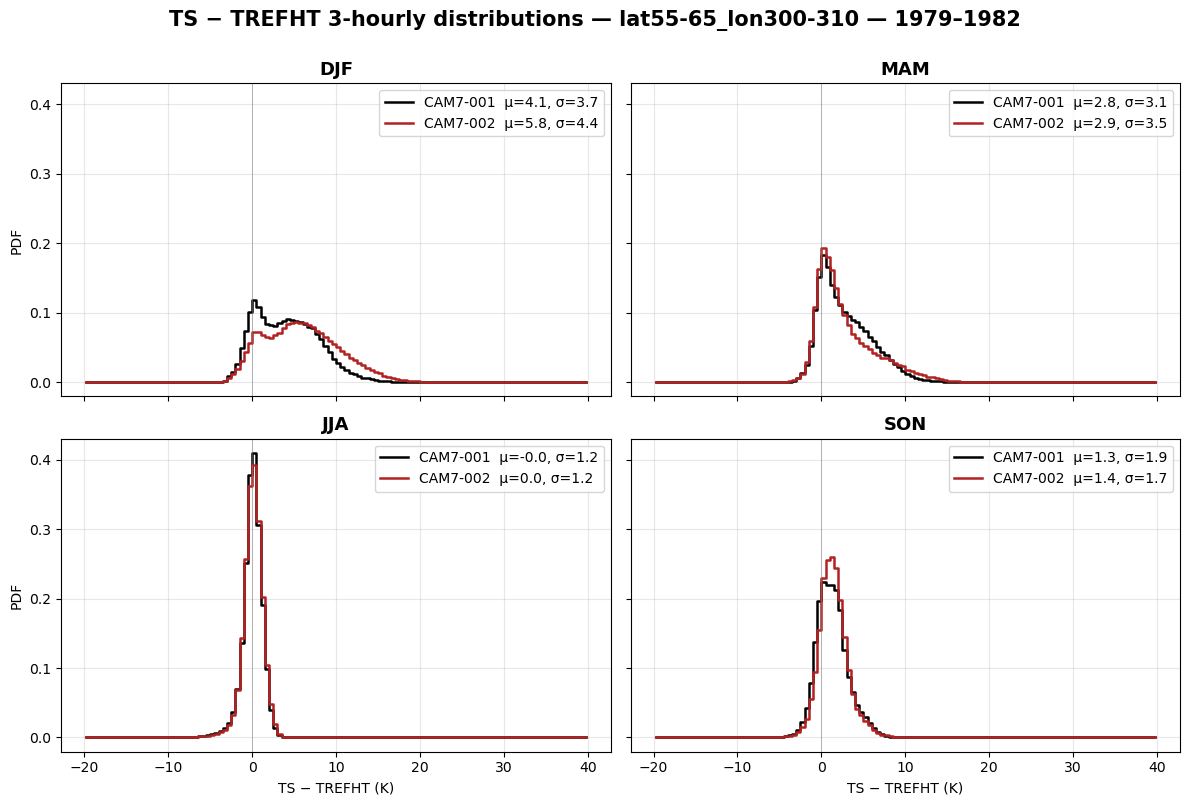

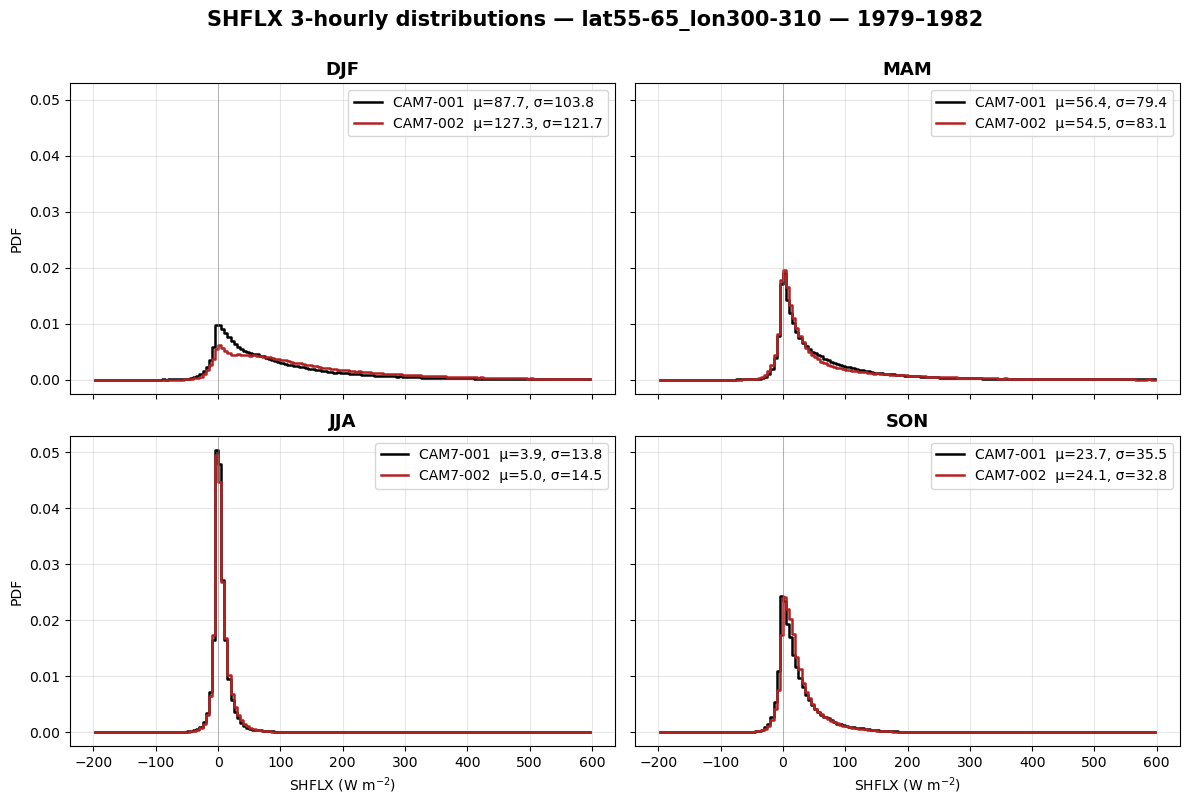

In [10]:
def counts_to_pdf(counts, bins):
    widths = np.diff(bins)
    total  = counts.sum()
    if total == 0:
        return np.zeros_like(widths, dtype=float)
    return counts / (total * widths)


def bin_stats(counts, bins):
    centers = 0.5 * (bins[:-1] + bins[1:])
    total = counts.sum()
    if total == 0:
        return float("nan"), float("nan")
    mean = float((centers * counts).sum() / total)
    var  = float(((centers - mean) ** 2 * counts).sum() / total)
    return mean, np.sqrt(var)


def plot_seasonal_pdfs(hists, var_key, region, save=True):
    """One figure per variable: 2×2 season grid, all cases overlaid."""
    m       = JOINT_VAR_META[var_key]
    bins    = JOINT_BINS[var_key]
    centers = 0.5 * (bins[:-1] + bins[1:])

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    for ax, season in zip(axes.flat, SEASONS):
        for name, entry in CASE_DATASETS.items():
            c   = hists[name][var_key][season]
            pdf = counts_to_pdf(c, bins)
            mean, std = bin_stats(c, bins)
            ax.step(centers, pdf, where="mid",
                    color=entry["color"], linestyle=entry["ls"], linewidth=1.8,
                    label=f"{name}  μ={mean:.1f}, σ={std:.1f}")
        ax.axvline(0, color="gray", linewidth=0.6, alpha=0.6)
        ax.set_title(season, fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10, loc="best")

    for ax in axes[-1, :]:
        ax.set_xlabel(f"{m['long']} ({m['units']})")
    for ax in axes[:, 0]:
        ax.set_ylabel("PDF")

    reg_tag = ("global" if region is None else
               f"lat{region['lat_min']:.0f}-{region['lat_max']:.0f}_"
               f"lon{region['lon_min']:.0f}-{region['lon_max']:.0f}")
    y0 = min(c["year_range"][0] for c in JOINT_CASES)
    y1 = max(c["year_range"][1] for c in JOINT_CASES)
    fig.suptitle(
        f"{m['long']} 3-hourly distributions — {reg_tag} — {y0}–{y1}",
        fontsize=15, fontweight="bold", y=1.00,
    )
    fig.tight_layout()

    if save:
        fname = os.path.join(FIG_DIR,
                             f"pdf_3hr_{var_key}_{reg_tag}_{y0}-{y1}.png")
        fig.savefig(fname, dpi=140, bbox_inches="tight")
        print(f"  saved {fname}")
    return fig, axes


for var_key in JOINT_VARS:
    plot_seasonal_pdfs(hists, var_key, REGION)
plt.show()


## % time above threshold

Threshold-exceedance frequency for each axis variable, derived from the
same pooled seasonal histograms as the 1-D PDF panel above.  Thresholds
are set in the config cell (`THRESHOLDS`) — defaults are 300 W m$^{-2}$
for SHFLX / LHFLX and 5 K for TS − TREFHT.

One figure per axis variable (`JOINT_X`, `JOINT_Y`); bars are grouped by
season with one bar per case.

  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/pct_above_3hr_TS_MINUS_TREFHT_gt10_lat55-65_lon300-310_1979-1982.png
  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/pct_above_3hr_SHFLX_gt300_lat55-65_lon300-310_1979-1982.png


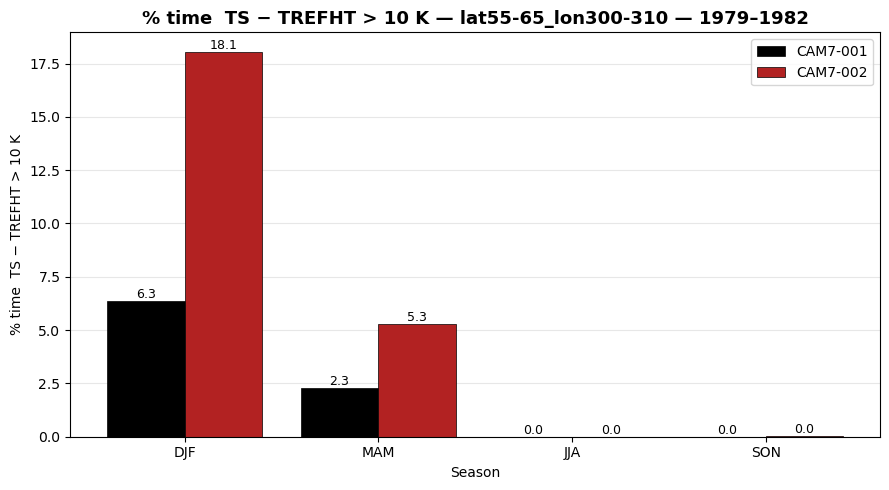

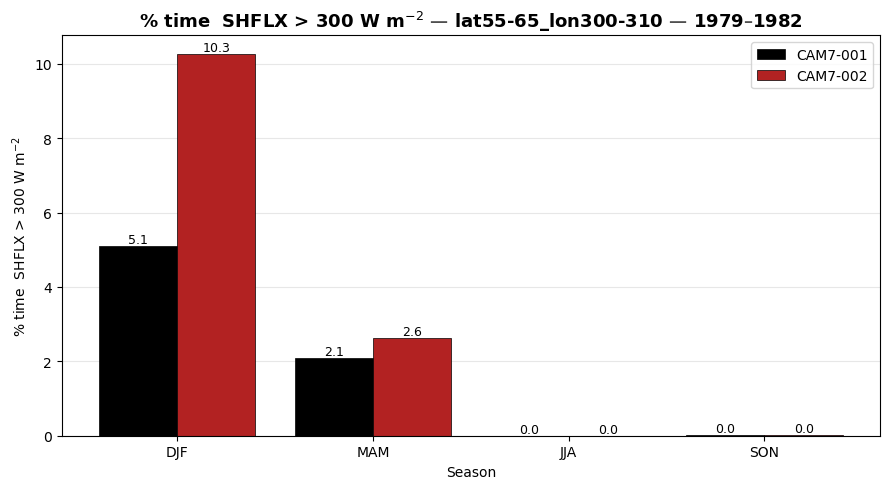

In [11]:
def pct_above_threshold(counts, bins, threshold):
    """Return the % of samples with value >= threshold from a 1-D histogram.

    If `threshold` falls inside a bin, that bin is split by linear
    interpolation so the answer is accurate even when the threshold isn't
    exactly on a bin edge.
    """
    total = counts.sum()
    if total == 0:
        return float("nan")
    if threshold <= bins[0]:
        return 100.0
    if threshold >= bins[-1]:
        return 0.0
    # bin i spans [bins[i], bins[i+1]); find the bin that contains threshold
    i = int(np.searchsorted(bins, threshold, side="right")) - 1
    frac_in_bin = (bins[i + 1] - threshold) / (bins[i + 1] - bins[i])
    above = counts[i] * frac_in_bin + counts[i + 1:].sum()
    return 100.0 * above / total


def plot_pct_above(hists, var_key, threshold, region, save=True):
    """Grouped bar chart: % time > threshold, one group per season, one bar per case."""
    m     = JOINT_VAR_META[var_key]
    bins  = JOINT_BINS[var_key]
    names = list(CASE_DATASETS.keys())
    ncase = len(names)

    fig, ax = plt.subplots(figsize=(9.0, 5.0))
    group_w = 0.8
    width   = group_w / ncase
    x       = np.arange(len(SEASONS))

    for i, name in enumerate(names):
        pcts = [pct_above_threshold(hists[name][var_key][s], bins, threshold)
                for s in SEASONS]
        offs = -group_w / 2 + width * (i + 0.5)
        bars = ax.bar(x + offs, pcts, width=width,
                      color=CASE_DATASETS[name]["color"],
                      edgecolor="black", linewidth=0.5, label=name)
        for xi, p in zip(x + offs, pcts):
            if np.isfinite(p):
                ax.text(xi, p, f"{p:.1f}",
                        ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(SEASONS)
    ax.set_xlabel("Season")
    ax.set_ylabel(f"% time  {m['long']} > {threshold:g} {m['units']}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10, loc="best")

    reg_tag = ("global" if region is None else
               f"lat{region['lat_min']:.0f}-{region['lat_max']:.0f}_"
               f"lon{region['lon_min']:.0f}-{region['lon_max']:.0f}")
    y0 = min(c["year_range"][0] for c in JOINT_CASES)
    y1 = max(c["year_range"][1] for c in JOINT_CASES)
    ax.set_title(
        f"% time  {m['long']} > {threshold:g} {m['units']} — "
        f"{reg_tag} — {y0}–{y1}",
        fontsize=13, fontweight="bold",
    )
    fig.tight_layout()

    if save:
        fname = os.path.join(
            FIG_DIR,
            f"pct_above_3hr_{var_key}_gt{threshold:g}_{reg_tag}_{y0}-{y1}.png",
        )
        fig.savefig(fname, dpi=140, bbox_inches="tight")
        print(f"  saved {fname}")
    return fig, ax


for var_key in JOINT_VARS:
    thr = THRESHOLDS.get(var_key)
    if thr is None:
        print(f"  {var_key}: no threshold set in THRESHOLDS — skipping")
        continue
    plot_pct_above(hists, var_key, thr, REGION)
plt.show()

## % time above threshold — ocean-only lat–lon maps (North Atlantic)

Same thresholds as the bar chart above, but computed **per grid point**
with land masked out (`LANDFRAC < 0.25` → keep) and zoomed to the North
Atlantic.  Each axis variable is re-loaded without the `REGION` slice —
the bar chart above still uses the region-pooled histograms.

One figure per axis variable, rows = cases, columns = seasons, colorbar
shared across all panels within a figure.  The `REGION` box is drawn on
each panel in red so the pooled statistics above can be located
spatially.

`LANDFRAC` is pulled from the first history file of each CAM case; ERA5
cases (no LANDFRAC in the `clean_3hr` archive) are plotted unmasked.
Adjust `NA_EXTENT` in the code cell below to reframe.

  sea-ice mask active for TS_MINUS_TREFHT: ICEFRAC < 0.2
  CAM7-001: no LANDFRAC — plotting unmasked
  CAM7-002: no LANDFRAC — plotting unmasked
  map CAM7-001     TS_MINUS_TREFHT  DJF (ocean, NA) ...  peak=42.4%
  map CAM7-001     TS_MINUS_TREFHT  MAM (ocean, NA) ...  peak=35.8%
  map CAM7-001     TS_MINUS_TREFHT  JJA (ocean, NA) ...  peak=38.3%
  map CAM7-001     TS_MINUS_TREFHT  SON (ocean, NA) ...  peak=37.7%
  map CAM7-002     TS_MINUS_TREFHT  DJF (ocean, NA) ...  peak=48.5%
  map CAM7-002     TS_MINUS_TREFHT  MAM (ocean, NA) ...  peak=35.7%
  map CAM7-002     TS_MINUS_TREFHT  JJA (ocean, NA) ...  peak=37.3%
  map CAM7-002     TS_MINUS_TREFHT  SON (ocean, NA) ...  peak=37.8%
  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/pct_above_map_3hr_TS_MINUS_TREFHT_gt10_natlantic_ocean_1979-1982.png
  CAM7-001: no LANDFRAC — plotting unmasked
  CAM7-002: no LANDFRAC — plotting unmasked
  map CAM7-001     SHFLX            DJF (ocean, NA) ...  peak=29.1%
  map CAM7-001  

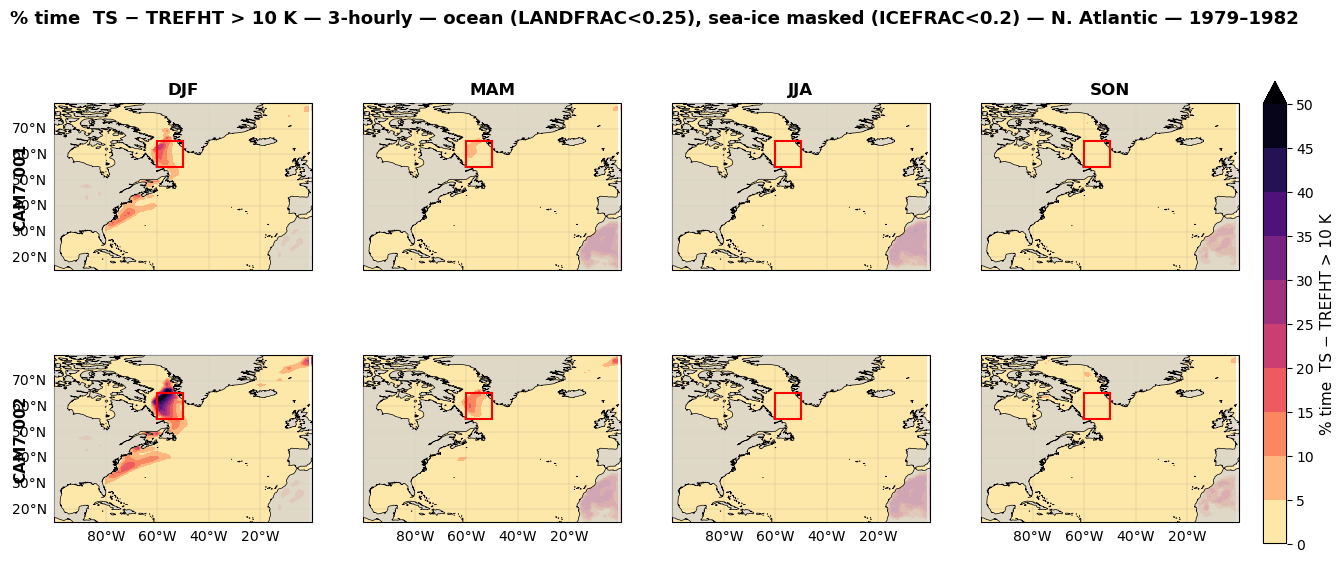

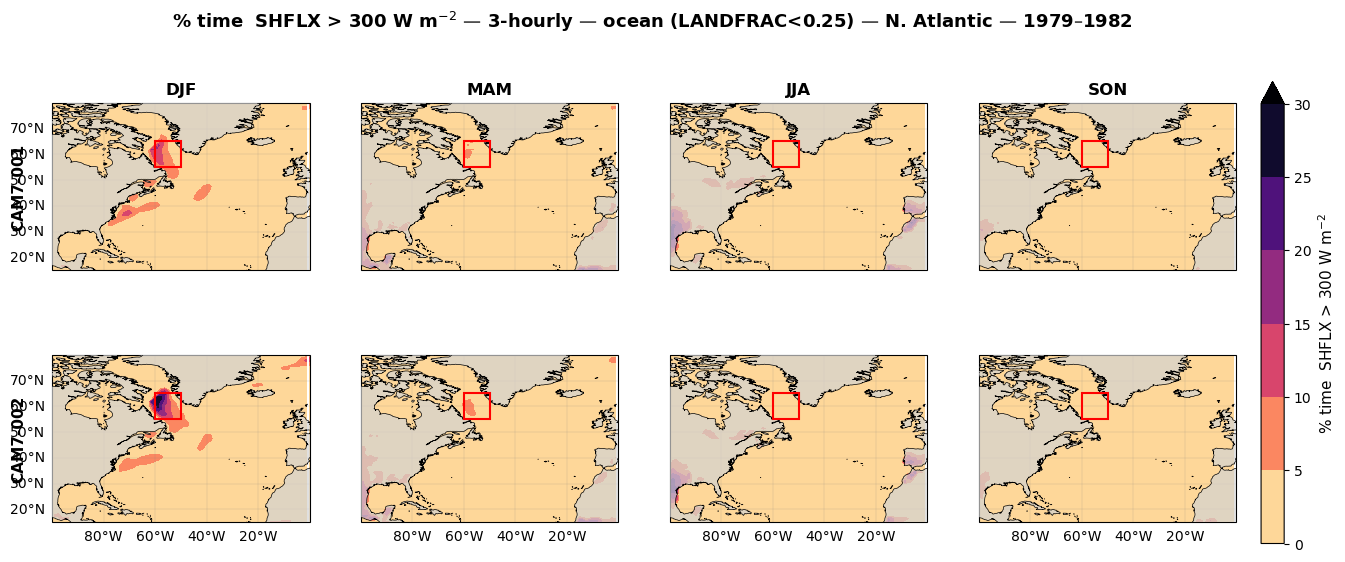

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches


# North Atlantic zoom for the maps: [lon_min, lon_max, lat_min, lat_max]
# (longitude in 0–360).
NA_EXTENT       = [260.0, 360.0, 15.0, 80.0]
OCEAN_LANDFRAC  = 0.25   # keep grid points with LANDFRAC < this


def _latlon_names(da):
    return (("latitude", "longitude") if "latitude" in da.coords
            else ("lat", "lon"))


def load_landfrac(cfg):
    """Return a static (lat, lon) LANDFRAC DataArray for one case, or None."""
    if cfg["kind"] == "cam":
        stream = cfg.get("stream", "h1i")
        files  = sorted(glob.glob(os.path.join(
            cfg["case_root"], f"*.cam.{stream}.*.nc")))
        if not files:
            return None
        ds = xr.open_dataset(files[0], decode_times=False)
        if "LANDFRAC" not in ds:
            return None
        lf = ds["LANDFRAC"]
        if "time" in lf.dims:
            lf = lf.isel(time=0, drop=True)
        return lf
    # ERA5 clean_3hr archive has no LSM — return None and skip masking.
    return None


def pct_above_map(da, time_name, season, threshold,
                  land_frac=None, ocean_max_land=OCEAN_LANDFRAC,
                  icefrac=None, seaice_threshold=None):
    """Per-grid-point % of season-in samples with value > threshold.
    If `land_frac` is given, mask grid points with LANDFRAC >= ocean_max_land.
    If `icefrac` is given, additionally mask grid points with ICEFRAC >= seaice_threshold."""
    is_season = da[time_name].dt.season == season
    da_s = da.where(is_season, drop=True)
    if da_s.sizes[time_name] == 0:
        return None
    n_valid = da_s.count(dim=time_name)
    above   = (da_s > threshold).sum(dim=time_name)
    pct = xr.where(n_valid > 0, 100.0 * above / n_valid, np.nan)
    if land_frac is not None:
        pct = pct.where(land_frac < ocean_max_land)
    if icefrac is not None and seaice_threshold is not None:
        pct = pct.where(icefrac < seaice_threshold)
    latn, lonn = _latlon_names(da_s)
    return pct.compute().sortby(latn).sortby(lonn)


def plot_pct_above_maps_na(var_key, threshold, save=True):
    """North-Atlantic, ocean-only % > threshold maps.

    Loads each axis variable WITHOUT the REGION slice, then masks land via
    each case's LANDFRAC (CAM only).  ERA5 variables in SEAICE_ERA5_VARS are
    additionally sea-ice masked using seasonal ICEFRAC from SEAICE_SEASONAL_CAM:
    grid points where ICEFRAC >= SEAICE_FRAC_THRESHOLD are excluded.
    Rows = cases, cols = seasons; shared colorbar.  REGION box in red.
    """
    m = JOINT_VAR_META[var_key]

    # Use global sea-ice mask for ERA5 variables that need it
    seaice_seasonal = SEAICE_SEASONAL_CAM if var_key in SEAICE_ERA5_VARS else None
    if seaice_seasonal:
        print(f"  sea-ice mask active for {var_key}: ICEFRAC < {SEAICE_FRAC_THRESHOLD}")

    # Build case entries: (name, DataArray, time-coord-name, landfrac, kind)
    entries = []
    for i, cfg in enumerate(JOINT_CASES):
        da = load_axis(cfg, var_key, cfg["year_range"], region=None)
        if da is None:
            print(f"  skipping {cfg['name']} for {var_key}: not in backend")
            continue
        tname = "valid_time" if cfg["kind"] == "era5" else "time"
        lf    = load_landfrac(cfg)
        if lf is None:
            print(f"  {cfg['name']}: no LANDFRAC — plotting unmasked")
        entries.append((cfg["name"], da, tname, lf, cfg["kind"]))
    if not entries:
        print(f"  no cases can supply {var_key} — nothing to plot")
        return None, None

    maps, vmax = {}, 0.0
    for name, da, tname, lf, kind in entries:
        maps[name] = {}
        for season in SEASONS:
            print(f"  map {name:12s} {var_key:16s} {season} (ocean, NA) ...",
                  end="", flush=True)
            # Sea-ice mask: ERA5 only, from global SEAICE_SEASONAL_CAM
            sic = None
            if seaice_seasonal is not None and kind == "era5":
                raw_sic = seaice_seasonal[season]   # DataArray(lat, lon) on CAM grid
                latn, lonn = _latlon_names(da)
                sic = raw_sic.sortby("lat").interp(
                    lat=da[latn].values,
                    lon=da[lonn].values,
                    method="linear",
                    kwargs={"fill_value": np.nan},
                ).rename({"lat": latn, "lon": lonn})
            p = pct_above_map(da, tname, season, threshold,
                              land_frac=lf,
                              icefrac=sic,
                              seaice_threshold=SEAICE_FRAC_THRESHOLD if sic is not None else None)
            maps[name][season] = p
            if p is not None:
                vmax = max(vmax, float(np.nanmax(p.values)))
                print(f"  peak={float(np.nanmax(p.values)):.1f}%")
            else:
                print("  (no samples)")
    if vmax <= 0.0:
        vmax = 1.0

    # Shared, tidy contour levels.
    step   = 5.0 if vmax <= 50 else (10.0 if vmax <= 100 else 20.0)
    top    = float(np.ceil(vmax / step) * step)
    levels = np.arange(0.0, top + step * 0.5, step)

    proj = ccrs.PlateCarree()
    nrow, ncol = len(entries), len(SEASONS)
    fig, axes = plt.subplots(nrow, ncol,
                              figsize=(4.0 * ncol, 3.0 * nrow),
                              subplot_kw={"projection": proj},
                              squeeze=False)

    im = None
    for i, (name, _, _, _, _) in enumerate(entries):
        for j, season in enumerate(SEASONS):
            ax = axes[i, j]
            p  = maps[name][season]
            if p is None:
                if i == 0:
                    ax.set_title(f"{season} — no data", fontsize=11)
                continue
            latn, lonn = _latlon_names(p)
            lon = p[lonn].values
            lat = p[latn].values
            Z   = p.values
            # Close contours across the 0/360 seam if the grid isn't cyclic.
            if lon[-1] - lon[0] < 360.0 - (lon[1] - lon[0]) * 1.5:
                lon = np.concatenate([lon, [lon[0] + 360.0]])
                Z   = np.concatenate([Z, Z[:, :1]], axis=1)
            im = ax.contourf(lon, lat, Z, levels=levels,
                              cmap="magma_r", extend="max",
                              transform=proj)
            # Land shading on top so masked land reads as land, not "no data".
            ax.add_feature(cfeature.LAND, facecolor="lightgray",
                            zorder=3, alpha=0.7)
            ax.coastlines(resolution="50m", linewidth=0.5, zorder=4)
            ax.set_extent(NA_EXTENT, crs=proj)
            if REGION is not None:
                rect = mpatches.Rectangle(
                    (REGION["lon_min"], REGION["lat_min"]),
                    REGION["lon_max"] - REGION["lon_min"],
                    REGION["lat_max"] - REGION["lat_min"],
                    linewidth=1.5, edgecolor="red", facecolor="none",
                    transform=proj, zorder=5,
                )
                ax.add_patch(rect)
            gl = ax.gridlines(draw_labels=(i == nrow - 1 or j == 0),
                               linewidth=0.3, color="gray", alpha=0.4)
            gl.top_labels = False
            gl.right_labels = False
            if i != nrow - 1:
                gl.bottom_labels = False
            if j != 0:
                gl.left_labels = False
            if i == 0:
                ax.set_title(season, fontsize=12, fontweight="bold")
        axes[i, 0].text(-0.10, 0.5, name,
                         transform=axes[i, 0].transAxes,
                         rotation=90, va="center", ha="right",
                         fontsize=11, fontweight="bold")

    if im is not None:
        cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                             orientation="vertical",
                             pad=0.02, fraction=0.025, extend="max",
                             ticks=levels)
        cbar.set_label(f"% time  {m['long']} > {threshold:g} {m['units']}",
                        fontsize=11)

    y0 = min(c["year_range"][0] for c in JOINT_CASES)
    y1 = max(c["year_range"][1] for c in JOINT_CASES)
    ice_note = (f", sea-ice masked (ICEFRAC<{SEAICE_FRAC_THRESHOLD})"
                if seaice_seasonal is not None else "")
    fig.suptitle(
        f"% time  {m['long']} > {threshold:g} {m['units']} — 3-hourly — "
        f"ocean (LANDFRAC<{OCEAN_LANDFRAC:g}){ice_note} — N. Atlantic — {y0}–{y1}",
        fontsize=13, fontweight="bold", y=1.00,
    )

    if save:
        fname = os.path.join(
            FIG_DIR,
            f"pct_above_map_3hr_{var_key}_gt{threshold:g}_natlantic_ocean_"
            f"{y0}-{y1}.png",
        )
        fig.savefig(fname, dpi=140, bbox_inches="tight")
        print(f"  saved {fname}")
    return fig, axes


for var_key in JOINT_VARS:
    thr = THRESHOLDS.get(var_key)
    if thr is None:
        print(f"  {var_key}: no threshold set in THRESHOLDS — skipping")
        continue
    plot_pct_above_maps_na(var_key, thr)
plt.show()

## Joint (X × Y) PDF — obs and model

Same sample pool as above, but binned in the **two-dimensional**
(`JOINT_X`, `JOINT_Y`) plane per season, for each entry in `JOINT_CASES`
(both defined in the top-of-notebook config cell — change axes, bins, or
cases there without touching this section).  Contour levels are
log-spaced so the low-probability tails are visible instead of being
squashed against the peak.

The output is one row per case followed by an optional **fractional-
difference row** `(P_b − P_a) / P_a` between the first two cases in
`JOINT_DATASETS` — set `show_diff=False` on `plot_joint_pdfs` to drop it,
or pass `diff_pair=("caseA", "caseB")` to pick a specific pair.  Bins
where either PDF is below the second-lowest PDF contour are masked out so
the diff panel doesn't get dominated by shot-noise in the tails.

**Data availability:** all five axis variables (`SHFLX`, `LHFLX`, `TS`,
`TREFHT`, `TS_MINUS_TREFHT`) come from the CAM h1i stream.  ERA5 in the
3-hourly `dcycle_3hrave` archive only carries `SHFLX`/`LHFLX`, so any
ERA5 case in `JOINT_CASES` is silently skipped when either axis needs
`TS` or `TREFHT`.


In [13]:
# Loaders and per-case datasets are already defined above (see cells 9 and
# 12).  Keep a `JOINT_DATASETS` alias so the 2-D flow below reads unchanged.
JOINT_DATASETS = CASE_DATASETS


In [14]:
from dask import delayed, compute

def joint_hist(x_da, y_da, time_name, season, xbins, ybins,
               icefrac=None, seaice_threshold=None):
    """2-D histogram of (x, y) samples for one season, streamed by dask block.

    Both DataArrays must share the same time/lat/lon shape *and* chunking.
    Out-of-season values are masked with NaN (via .where) so the block-level
    np.histogram2d call transparently drops them.  If `icefrac` is given,
    grid points with ICEFRAC >= seaice_threshold are also excluded from both
    x and y simultaneously, preserving spatial correspondence.
    """
    mask = x_da[time_name].dt.season == season
    x = x_da.where(mask)
    y = y_da.where(mask)
    if icefrac is not None and seaice_threshold is not None:
        latn = "latitude" if "latitude" in x_da.coords else "lat"
        lonn = "longitude" if "longitude" in x_da.coords else "lon"
        sic = icefrac.sortby("lat").interp(
            lat=x_da[latn].values, lon=x_da[lonn].values,
            method="linear", kwargs={"fill_value": np.nan},
        ).rename({"lat": latn, "lon": lonn})
        x = x.where(sic < seaice_threshold)
        y = y.where(sic < seaice_threshold)
    x = x.data
    y = y.data
    xb = list(x.to_delayed().ravel())
    yb = list(y.to_delayed().ravel())

    def _h(xarr, yarr, xbins=xbins, ybins=ybins):
        xv = np.asarray(xarr).ravel()
        yv = np.asarray(yarr).ravel()
        m  = np.isfinite(xv) & np.isfinite(yv)
        h, _, _ = np.histogram2d(xv[m], yv[m], bins=[xbins, ybins])
        return h

    tasks = [delayed(_h)(a, b) for a, b in zip(xb, yb)]
    return sum(compute(*tasks))


joint = {}   # joint[dataset_name][season] → 2-D count array
for name, d in JOINT_DATASETS.items():
    joint[name] = {}
    is_era5 = d["time"] == "valid_time"
    needs_sic = is_era5 and (JOINT_X in SEAICE_ERA5_VARS or JOINT_Y in SEAICE_ERA5_VARS)
    for season in SEASONS:
        print(f"  joint {name:10s} {season} ...", end="", flush=True)
        sic = SEAICE_SEASONAL_CAM.get(season) if needs_sic else None
        joint[name][season] = joint_hist(d["x"], d["y"], d["time"],
                                          season, x_bins, y_bins,
                                          icefrac=sic,
                                          seaice_threshold=SEAICE_FRAC_THRESHOLD if sic is not None else None)
        print(f"  n={joint[name][season].sum():,.0f}, "
              f"peak={joint[name][season].max():,.0f}")

  joint CAM7-001   DJF ...  n=251,728, peak=8,641
  joint CAM7-001   MAM ...  n=258,965, peak=16,278
  joint CAM7-001   JJA ...  n=259,072, peak=41,099
  joint CAM7-001   SON ...  n=256,256, peak=19,770
  joint CAM7-002   DJF ...  n=251,718, peak=4,977
  joint CAM7-002   MAM ...  n=259,037, peak=17,487
  joint CAM7-002   JJA ...  n=259,072, peak=37,748
  joint CAM7-002   SON ...  n=256,256, peak=20,229


  saved /glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/LabSea/joint_pdf_3hr_TS_MINUS_TREFHT_SHFLX_lat55-65_lon300-310_1979-1982_CAM7-001_CAM7-002.png


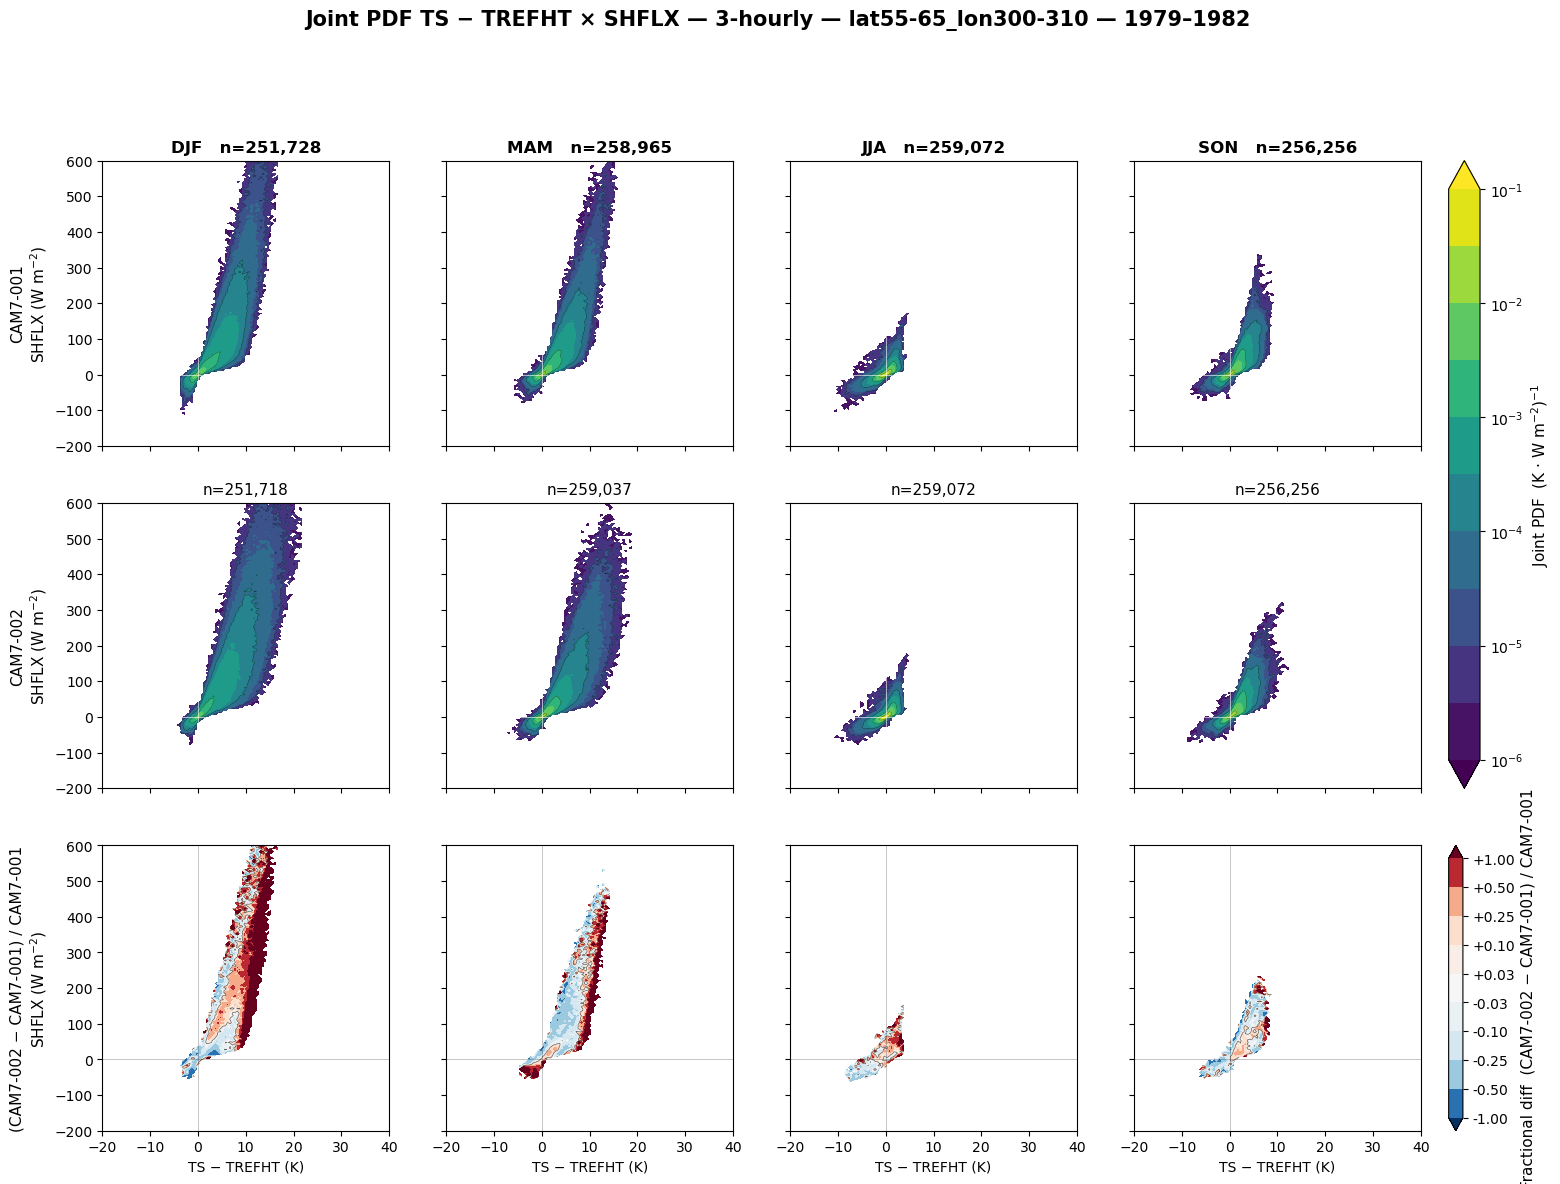

In [15]:
from matplotlib.colors import LogNorm

def joint_pdf(counts, xbins, ybins):
    total = counts.sum()
    area  = np.outer(np.diff(xbins), np.diff(ybins))
    return counts / (total * area) if total else np.zeros_like(counts, dtype=float)


def _decade_levels(peak, n_decades, per_decade=2):
    """Log-spaced contour levels + tick positions on clean decade boundaries.

    * `peak` is rounded UP to the next power of 10 to give a tidy top.
    * `n_decades` full decades are covered below that.
    * `per_decade` = 2 → half-decade contour steps.
    * Ticks land on the full decades only, so the colorbar reads
      10^-N … 10^-M with no in-between scientific-notation clutter.
    """
    log_hi = int(np.ceil(np.log10(peak)))
    log_lo = log_hi - n_decades
    levels   = 10.0 ** np.arange(log_lo, log_hi + 1e-9, 1.0 / per_decade)
    tick_pos = 10.0 ** np.arange(log_lo, log_hi + 1e-9, 1.0)
    tick_lab = [rf"$10^{{{int(round(np.log10(t)))}}}$" for t in tick_pos]
    return levels, tick_pos, tick_lab


def plot_joint_pdfs(joint, xbins, ybins, xkey, ykey,
                    xlim=None, ylim=None, n_decades=5,
                    show_diff=True, diff_pair=None, save=True):
    """Grid of joint (xkey, ykey) PDFs — rows = datasets, cols = seasons.

    Contour levels are shared across all PDF panels and log-spaced on clean
    decade boundaries so the colorbar labels read as tidy 10^-N.
    xlim/ylim default to the bin range if not supplied.

    If `show_diff` and at least two cases are present, a bottom row is
    appended with the fractional difference  (P_b − P_a) / P_a  for a
    chosen pair `(a, b)` (defaults to the first two entries of `joint`).
    Bins where either PDF is below the second-lowest PDF contour are
    masked so the diff panel isn't dominated by shot-noise in the tails.
    """
    xmeta = JOINT_VAR_META[xkey]
    ymeta = JOINT_VAR_META[ykey]
    xc = 0.5 * (xbins[:-1] + xbins[1:])
    yc = 0.5 * (ybins[:-1] + ybins[1:])
    if xlim is None: xlim = (xbins[0], xbins[-1])
    if ylim is None: ylim = (ybins[0], ybins[-1])

    names = list(joint.keys())
    has_diff = show_diff and len(names) >= 2
    if has_diff:
        a, b = diff_pair if diff_pair is not None else (names[0], names[1])
    nrow_pdf = len(names)
    nrow     = nrow_pdf + (1 if has_diff else 0)
    ncol     = len(SEASONS)

    # Precompute all PDFs
    pdfs = {n: {s: joint_pdf(joint[n][s], xbins, ybins) for s in SEASONS}
            for n in names}
    peak = max(pdfs[n][s].max() for n in names for s in SEASONS)
    levels, tick_pos, tick_lab = _decade_levels(peak, n_decades)
    norm = LogNorm(vmin=levels[0], vmax=levels[-1])
    diff_mask_floor = levels[1]   # noise threshold for the diff row

    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 4.2 * nrow),
                              sharex=True, sharey=True, squeeze=False)

    # ── PDF rows ───────────────────────────────────────────────────────
    for i, name in enumerate(names):
        for j, season in enumerate(SEASONS):
            ax = axes[i, j]
            Z = np.ma.masked_less_equal(pdfs[name][season].T, 0.0)
            im = ax.contourf(xc, yc, Z, levels=levels, norm=norm,
                              cmap="viridis", extend="both")
            ax.contour(xc, yc, Z, levels=tick_pos, colors="k",
                        linewidths=0.4, alpha=0.5, norm=norm)
            if xlim[0] < 0 < xlim[1]:
                ax.axvline(0, color="w", lw=0.6, alpha=0.7)
            if ylim[0] < 0 < ylim[1]:
                ax.axhline(0, color="w", lw=0.6, alpha=0.7)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

            n = joint[name][season].sum()
            if i == 0:
                ax.set_title(f"{season}   n={n:,.0f}",
                             fontsize=12, fontweight="bold")
            else:
                ax.set_title(f"n={n:,.0f}", fontsize=11)

        axes[i, 0].set_ylabel(f"{name}\n{ymeta['long']} ({ymeta['units']})",
                              fontsize=11)

    # ── Diff row ───────────────────────────────────────────────────────
    if has_diff:
        # Symmetric fractional-diff levels centred on 0.
        diff_levels = np.array([-1.0, -0.5, -0.25, -0.10, -0.03,
                                 0.03,  0.10,  0.25,  0.50,  1.0])
        for j, season in enumerate(SEASONS):
            ax = axes[nrow_pdf, j]
            Pa = pdfs[a][season]
            Pb = pdfs[b][season]
            with np.errstate(divide="ignore", invalid="ignore"):
                D = np.where(Pa > 0, (Pb - Pa) / Pa, np.nan)
            D = np.ma.masked_where(
                (Pa < diff_mask_floor) | (Pb < diff_mask_floor)
                | ~np.isfinite(D),
                D,
            )
            im_d = ax.contourf(xc, yc, D.T, levels=diff_levels,
                                cmap="RdBu_r", extend="both")
            ax.contour(xc, yc, D.T, levels=[0.0], colors="k",
                        linewidths=0.5, alpha=0.6)
            if xlim[0] < 0 < xlim[1]:
                ax.axvline(0, color="k", lw=0.4, alpha=0.4)
            if ylim[0] < 0 < ylim[1]:
                ax.axhline(0, color="k", lw=0.4, alpha=0.4)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_title("", fontsize=11)

        axes[nrow_pdf, 0].set_ylabel(
            f"({b} − {a}) / {a}\n{ymeta['long']} ({ymeta['units']})",
            fontsize=11,
        )

    # X labels on bottom row only
    for ax in axes[-1, :]:
        ax.set_xlabel(f"{xmeta['long']} ({xmeta['units']})")

    # ── Colorbars: one for PDF rows, one (below it) for the diff row ──
    if xmeta["units"] == ymeta["units"]:
        cbar_units = f"({xmeta['units']})$^{{-2}}$"
    else:
        cbar_units = f"({xmeta['units']} · {ymeta['units']})$^{{-1}}$"

    cbar = fig.colorbar(
        im, ax=axes[:nrow_pdf, :].ravel().tolist(),
        orientation="vertical", pad=0.02, fraction=0.035,
        extend="both", ticks=tick_pos,
    )
    cbar.ax.set_yticklabels(tick_lab)
    cbar.set_label(f"Joint PDF  {cbar_units}", fontsize=11)

    if has_diff:
        cbar_d = fig.colorbar(
            im_d, ax=axes[nrow_pdf:, :].ravel().tolist(),
            orientation="vertical", pad=0.02, fraction=0.035,
            extend="both", ticks=diff_levels,
        )
        cbar_d.ax.set_yticklabels([f"{v:+.2f}" if v != 0 else "0"
                                    for v in diff_levels])
        cbar_d.set_label(f"Fractional diff  ({b} − {a}) / {a}", fontsize=11)

    reg_tag = ("global" if REGION is None else
               f"lat{REGION['lat_min']:.0f}-{REGION['lat_max']:.0f}_"
               f"lon{REGION['lon_min']:.0f}-{REGION['lon_max']:.0f}")
    y0 = min(c["year_range"][0] for c in JOINT_CASES)
    y1 = max(c["year_range"][1] for c in JOINT_CASES)
    fig.suptitle(
        f"Joint PDF {xmeta['long']} × {ymeta['long']} — 3-hourly — "
        f"{reg_tag} — {y0}–{y1}",
        fontsize=15, fontweight="bold", y=1.00,
    )

    if save:
        fname = os.path.join(
            FIG_DIR,
            f"joint_pdf_3hr_{xkey}_{ykey}_{reg_tag}_{y0}-{y1}_"
            f"{'_'.join(names)}.png",
        )
        fig.savefig(fname, dpi=140, bbox_inches="tight")
        print(f"  saved {fname}")

    return fig, axes


plot_joint_pdfs(joint, x_bins, y_bins, JOINT_X, JOINT_Y)
plt.show()
